# Export HRCA results

In [1]:
from pathlib import Path
import scanpy as sc
sc.set_figure_params(frameon=False, dpi=80, fontsize=12)

from scatlastb_utils.io import read_anndata, write_zarr

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
def export_anndata(in_file, out_file):
    adata = read_anndata(
        in_file,
        stride=200_00,
        dask=True,
        backed=True,
        verbose=False
    )
    del adata.layers['normcounts']
    adata.layers['counts'] = adata.layers['counts'].map_blocks(
        lambda x: x.astype('int32'),
        dtype='int32'
    )
    
    print('set colors of majority consensus')
    adata.obs['majority_consensus'] = adata.obs['majority_consensus'].cat.set_categories(
        adata.obs['ann_finest_level'].cat.categories
    )
    
    print('set majority_consensus_disagreement')
    adata.obs['majority_consensus_disagreement'] = 1 - adata.obs['majority_consensus_agreement']
    
    print('Write to zarr...')
    write_zarr(adata, out_file, compute=False)
    del adata

In [27]:
in_file_pattern = 'data/pipeline/HRCA/majority_voting/dataset~{lineage}/file_id~collect:{lineage}.zarr'
out_dir = 'data/output/HRCA'
out_file_pattern = f'{out_dir}/{{lineage}}.zarr'
out_file_export_pattern = f'{out_dir}/export/{{lineage}}.zarr.tar.lz4'

In [4]:
for lineage in ['AC', 'BC', 'RGC']:
    print(f'{lineage=}')
    in_file = in_file_pattern.format(lineage=lineage)
    out_file = out_file_pattern.format(lineage=lineage)
    out_file_export = out_file_export_pattern.format(lineage=lineage)
    
    export_anndata(in_file, out_file)

lineage='AC'
set colors of majority consensus
set majority_consensus_disagreement
Write to zarr...
lineage='BC'
set colors of majority consensus
set majority_consensus_disagreement
Write to zarr...
lineage='RGC'
set colors of majority consensus
set majority_consensus_disagreement
Write to zarr...


## Extra output for scimilarity on RGC

In [18]:
adata = read_anndata(
    'data/pipeline/HRCA/majority_voting/dataset~RGC/file_id~collect:RGC.zarr',
    obs='obs',
    obsm='obsm',
    obsp='obsp',
    verbose=False
)

In [19]:
adata.obs['majority_consensus'] = adata.obs['majority_consensus'].cat.set_categories(
    adata.obs['ann_finest_level'].cat.categories
)
adata.obs['majority_consensus_disagreement'] = 1 - adata.obs['majority_consensus_agreement']

In [22]:
# keep only scimilarity
for col in adata.obs.columns:
    if 'scimilarity' in col or '--metrics:' not in col:
        continue
    del adata.obs[col]

for key in list(adata.obsm.keys()):
    if 'scimilarity' in key:
        continue
    del adata.obsm[key]
    
for key in list(adata.obsp.keys()):
    if 'scimilarity' in key:
        continue
    del adata.obsp[key]

In [23]:
adata

AnnData object with n_obs × n_vars = 399605 × 0
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', 'RGC_cluster', 'RGC_cellt

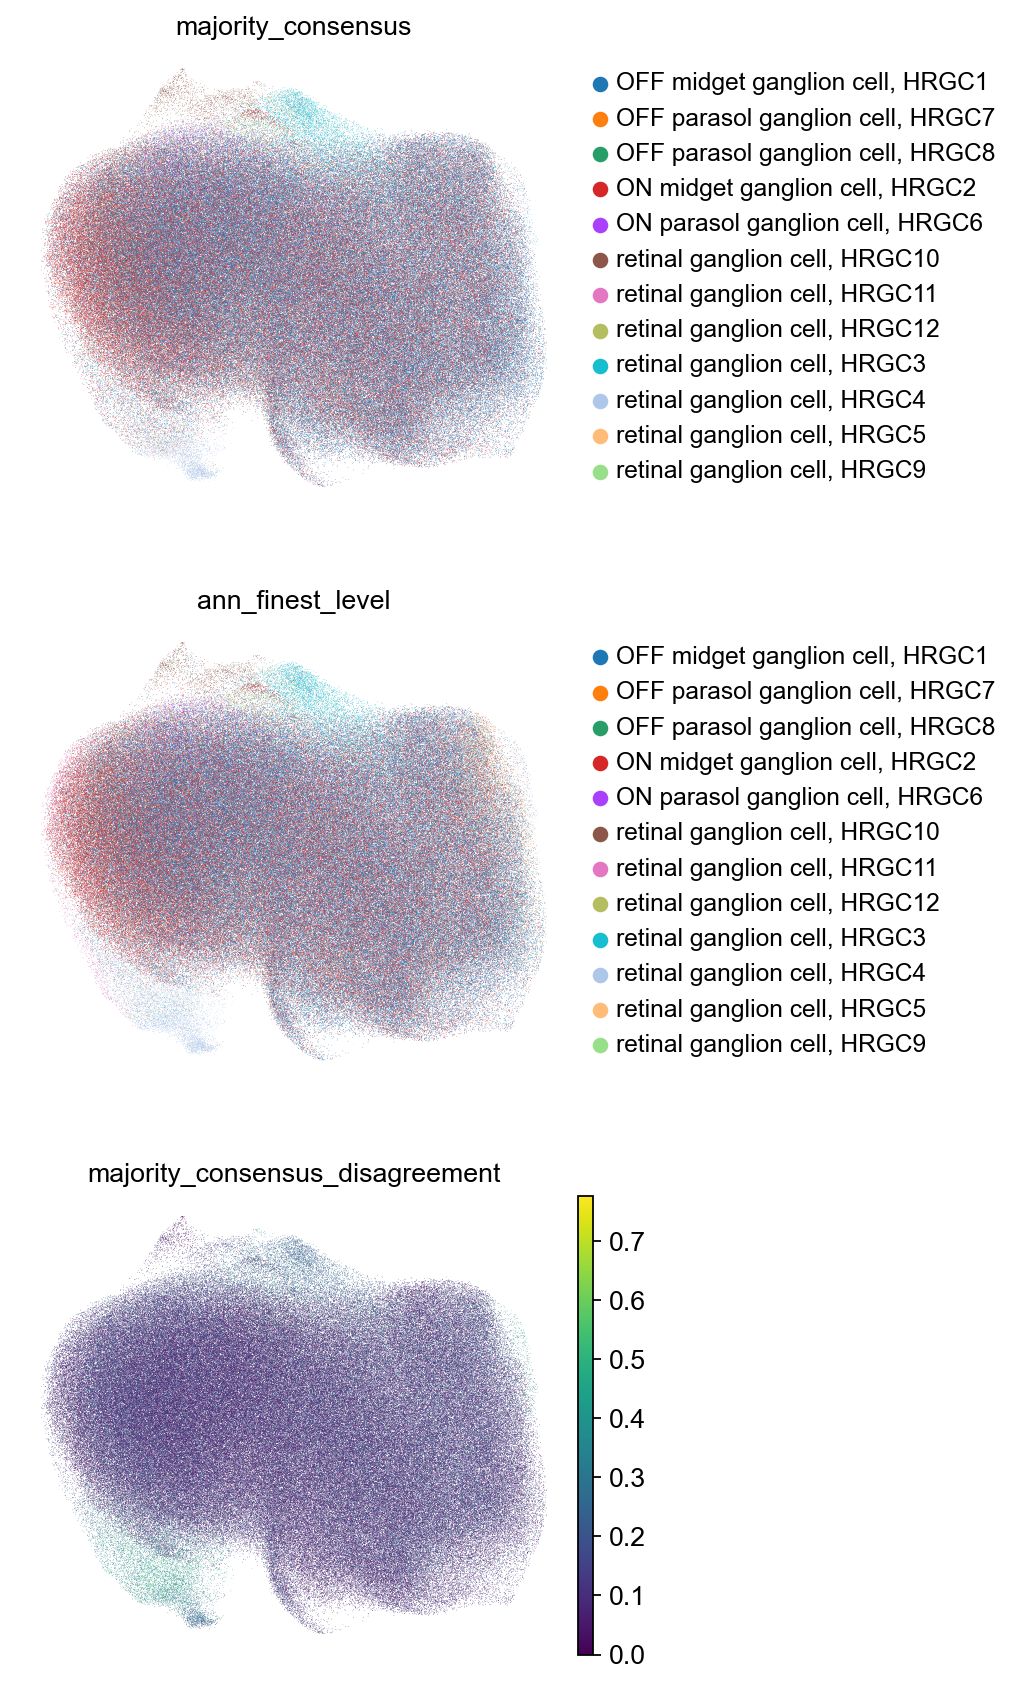

In [14]:
sc.pl.embedding(
    adata,
    basis='X_umap--metrics:scimilarity',
    color=['majority_consensus', 'ann_finest_level', 'majority_consensus_disagreement'],
    ncols=1,
    frameon=False,
)

In [36]:
print('Write to zarr...')
write_zarr(adata, 'data/output/HRCA/RGC_scimilarity.zarr')

Write to zarr...


## Compress data and upload

In [37]:
for lineage in ['AC', 'BC', 'RGC', 'RGC_scimilarity']:
    output_zarr = out_file_pattern.format(lineage=lineage)
    output_lz4 = out_file_export_pattern.format(lineage=lineage)
    print(f'Compress {lineage} to {output_lz4}...')
    !tar -cf - {output_zarr} | lz4 -9 > {output_lz4}

Compress AC to data/output/HRCA/export/AC.zarr.tar.lz4...
Compress BC to data/output/HRCA/export/BC.zarr.tar.lz4...
Compress RGC to data/output/HRCA/export/RGC.zarr.tar.lz4...
Compress RGC_scimilarity to data/output/HRCA/export/RGC_scimilarity.zarr.tar.lz4...


In [29]:
!du -hd1 {Path(out_file_pattern).parent}

13G	data/output/HRCA/RGC.zarr
476M	data/output/HRCA/RGC_scimilarity.zarr
35G	data/output/HRCA/export
14G	data/output/HRCA/BC.zarr
14G	data/output/HRCA/AC.zarr
76G	data/output/HRCA


In [34]:
ll -h {Path(out_file_export_pattern).parent}

total 35G
-rw-r--r-- 1 michaela.mueller 12G Feb 10 08:19 AC.zarr.tar.lz4
-rw-r--r-- 1 michaela.mueller 12G Feb 10 08:30 BC.zarr.tar.lz4
-rw-r--r-- 1 michaela.mueller 11G Feb 10 08:42 RGC.zarr.tar.lz4


In [40]:
!rclone copy --stats=10s --stats-one-line --log-level NOTICE \
    "{Path(out_file_export_pattern).parent}" onedrive:scAtlasTb/HRCA/output

2026/03/06 04:33:06 INFO  :       220 MiB / 35.888 GiB, 1%, 22.000 MiB/s, ETA 27m40s
2026/03/06 04:33:16 INFO  :       550 MiB / 35.888 GiB, 1%, 27.715 MiB/s, ETA 21m46s
2026/03/06 04:33:26 INFO  :       850 MiB / 35.888 GiB, 2%, 28.807 MiB/s, ETA 20m46s
2026/03/06 04:33:36 INFO  :     1.122 GiB / 35.888 GiB, 3%, 29.315 MiB/s, ETA 20m14s
2026/03/06 04:33:46 INFO  :     1.374 GiB / 35.888 GiB, 4%, 27.643 MiB/s, ETA 21m18s
2026/03/06 04:33:56 INFO  :     1.650 GiB / 35.888 GiB, 5%, 28.005 MiB/s, ETA 20m51s
2026/03/06 04:34:06 INFO  :     1.934 GiB / 35.888 GiB, 5%, 28.397 MiB/s, ETA 20m24s
2026/03/06 04:34:16 INFO  :     2.236 GiB / 35.888 GiB, 6%, 29.548 MiB/s, ETA 19m26s
2026/03/06 04:34:26 INFO  :     2.538 GiB / 35.888 GiB, 7%, 30.122 MiB/s, ETA 18m53s
2026/03/06 04:34:36 INFO  :     2.835 GiB / 35.888 GiB, 8%, 30.493 MiB/s, ETA 18m29s
2026/03/06 04:34:46 INFO  :     3.115 GiB / 35.888 GiB, 9%, 29.383 MiB/s, ETA 19m2s
2026/03/06 04:34:56 INFO  :     3.398 GiB / 35.888 GiB, 9%, 29.297